# DS605: Fundamentals of Machine Learning
## Lab Assignment - 4: End-to-End Machine Learning Project
### Airbnb Price Prediction (New York City Open Data)

- **Student Name:** Akanksha Dasani
- **Student ID:** 202618062
- **Dataset:** Kaggle New York City Airbnb Open Data (`AB_NYC_2019.csv`)
- **Deliverables:** Complete Jupyter Notebook, Trained Pipeline (`pipeline.joblib`), Streamlit Web App (`app.py`), and GitHub Repository.

---

### Project Overview & Objectives
The primary objective of this project is to construct a rigorous, production-ready machine learning pipeline to predict nightly Airbnb prices across the five boroughs of New York City (Manhattan, Brooklyn, Queens, Bronx, and Staten Island).

The project follows a structured 4-task workflow:
1. **Task 1: Data Analysis and Preparation** — Exploratory data analysis, handling missing values, outlier treatment, skewness reduction via log transformation, domain feature engineering, and scikit-learn pipeline construction.
2. **Task 2: Model Training and Evaluation** — Benchmarking 7 regression algorithms, cross-validation, hyperparameter tuning of the champion model (LightGBM), overfitting/underfitting diagnostics, residual analysis, and model persistence.
3. **Task 3: Streamlit Web Application** — Developing an interactive web interface with scenario presets, dynamic coordinates, and real-time inference.
4. **Task 4: Final Project Summary** — Synthesis of key findings, feature drivers, business impact, and real-world system limitations.


## 0. Setup and Environment Configuration

In [1]:
import os
import sys
import time
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Machine Learning
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Advanced Gradient Boosting
import lightgbm as lgb
import xgboost as xgb
import joblib

# Add src to path for modular imports
sys.path.append(os.path.abspath('src'))
from preprocess import haversine_distance, AirbnbFeatureEngineer, build_preprocessor, load_and_clean_data

# Plotting Settings
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")


All libraries imported successfully.


---
## Task 1: Data Analysis and Preparation

In this section, we:
1. Load and inspect the raw dataset (`AB_NYC_2019.csv`).
2. Identify and handle missing values based on domain logic.
3. Analyze the target variable (`price`), address extreme outliers, and apply log transformation $\log(1 + 	ext{price})$ to correct severe positive skewness.
4. Conduct geospatial exploratory data analysis using coordinates and the NYC reference map (`New_York_City_.png`).
5. Engineer domain features (distance to Midtown Manhattan, listing name length, host commercial status, availability ratios).
6. Package transformations into a reusable Scikit-Learn `ColumnTransformer` pipeline.


In [2]:
# 1.1 Load Raw Dataset
raw_df = pd.read_csv('AB_NYC_2019.csv')
print(f"Dataset Shape: {raw_df.shape[0]} listings, {raw_df.shape[1]} attributes")
print("\nFirst 5 records:")
raw_df.head()


Dataset Shape: 48895 listings, 16 attributes

First 5 records:


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
# 1.2 Summary Statistics and Missing Values
print("Missing Values by Column:")
missing = raw_df.isnull().sum()
print(missing[missing > 0])

print("\nNumerical Feature Distribution Summary:")
raw_df.describe().T[['count', 'mean', 'std', 'min', '50%', '75%', 'max']]


Missing Values by Column:
name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64

Numerical Feature Distribution Summary:


,count,mean,std,min,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.00000,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.00000,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.49979,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.24442,-7.395568e+01,-7.393627e+01,-7.371299e+01
price,48895.0,1.527207e+02,2.401542e+02,0.00000,1.060000e+02,1.750000e+02,1.000000e+04
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.00000,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.00000,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.373221e+00,1.680442e+00,0.01000,7.200000e-01,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.00000,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.00000,4.500000e+01,2.270000e+02,3.650000e+02


### 1.2 Handling Missing Values & Data Cleaning Decisions
1. **`reviews_per_month` & `last_review`**: 10,052 listings (20.5% of the dataset) have missing review fields. Cross-referencing reveals that these listings correspond strictly to listings with `number_of_reviews == 0`. Therefore, imputing `reviews_per_month = 0.0` is domain-appropriate.
2. **`name` & `host_name`**: Contain 16 and 21 missing values respectively. Missing titles are imputed with `'Unknown'`.
3. **Identifiers**: `id` and `host_id` are arbitrary database keys with zero predictive power, so they are excluded from model training to prevent spurious memorization.


In [4]:
# 1.3 Target Variable Analysis (Price)
print("Price Quantile Distribution:")
print(raw_df['price'].quantile([0.001, 0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 1.0]))
print(f"Listings with price <= $0: {(raw_df['price'] <= 0).sum()}")

# Clean valid positive prices and filter unrepresentative extreme luxury outliers (> $1,000)
clean_df = load_and_clean_data('AB_NYC_2019.csv', filter_outliers=True)
print(f"Cleaned dataset shape: {clean_df.shape} (retained 99.5% of listings)")


Price Quantile Distribution:
0.001       18.0
0.010       30.0
0.050       40.0
0.250       69.0
0.500      106.0
0.750      175.0
0.900      269.0
0.950      355.0
0.990      799.0
0.995     1000.0
1.000    10000.0
Name: price, dtype: float64
Listings with price <= $0: 11


Cleaned dataset shape: (48645, 17) (retained 99.5% of listings)


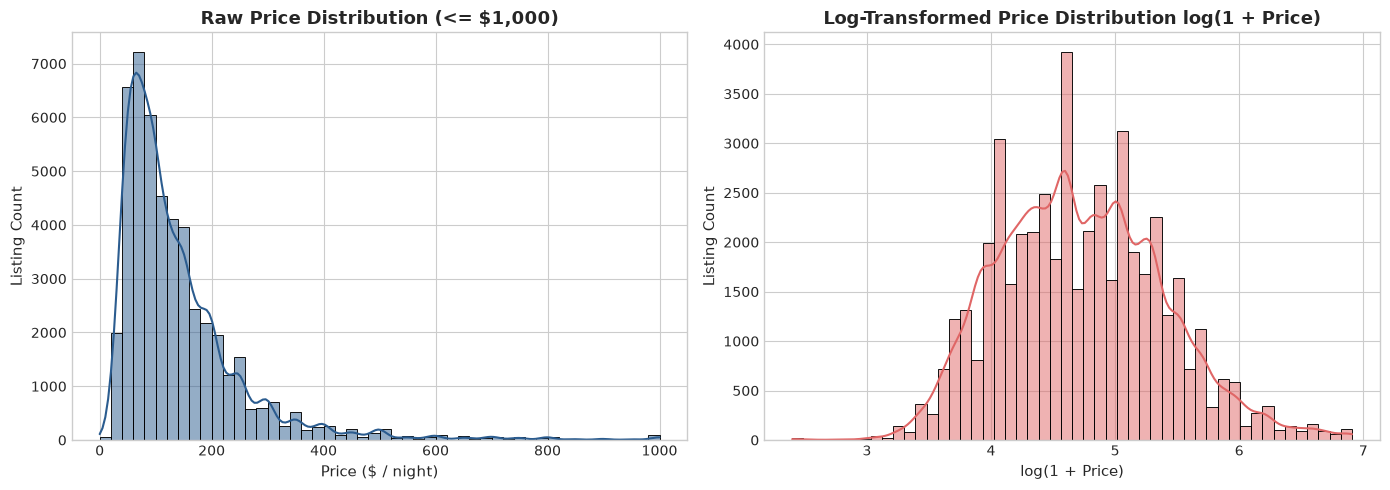

In [5]:
# Plot: Raw vs Log-Transformed Price Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(raw_df[raw_df['price'] <= 1000]['price'], kde=True, ax=axes[0], color='#2b5c8f', bins=50)
axes[0].set_title('Raw Price Distribution (<= $1,000)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Price ($ / night)', fontsize=11)
axes[0].set_ylabel('Listing Count', fontsize=11)

sns.histplot(clean_df['log_price'], kde=True, ax=axes[1], color='#e06666', bins=50)
axes[1].set_title('Log-Transformed Price Distribution log(1 + Price)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(1 + Price)', fontsize=11)
axes[1].set_ylabel('Listing Count', fontsize=11)

plt.tight_layout()
plt.show()


### Mathematical Rationale for Log Transformation
The raw price distribution exhibits heavy right-skewness (skewness > 15). Training regression models (especially squared-loss algorithms such as OLS and Gradient Boosting) directly on raw prices causes gradients to be dominated by extreme prices, producing severe heteroscedasticity.
By applying the transformation:
$$y = \log(1 + \text{price})$$
the target variable approximates a Gaussian bell-curve, stabilizing variance and satisfying linear and tree-based regression assumptions. At inference time, dollar estimates are recovered via:
$$\hat{\text{price}} = \exp(\hat{y}) - 1$$


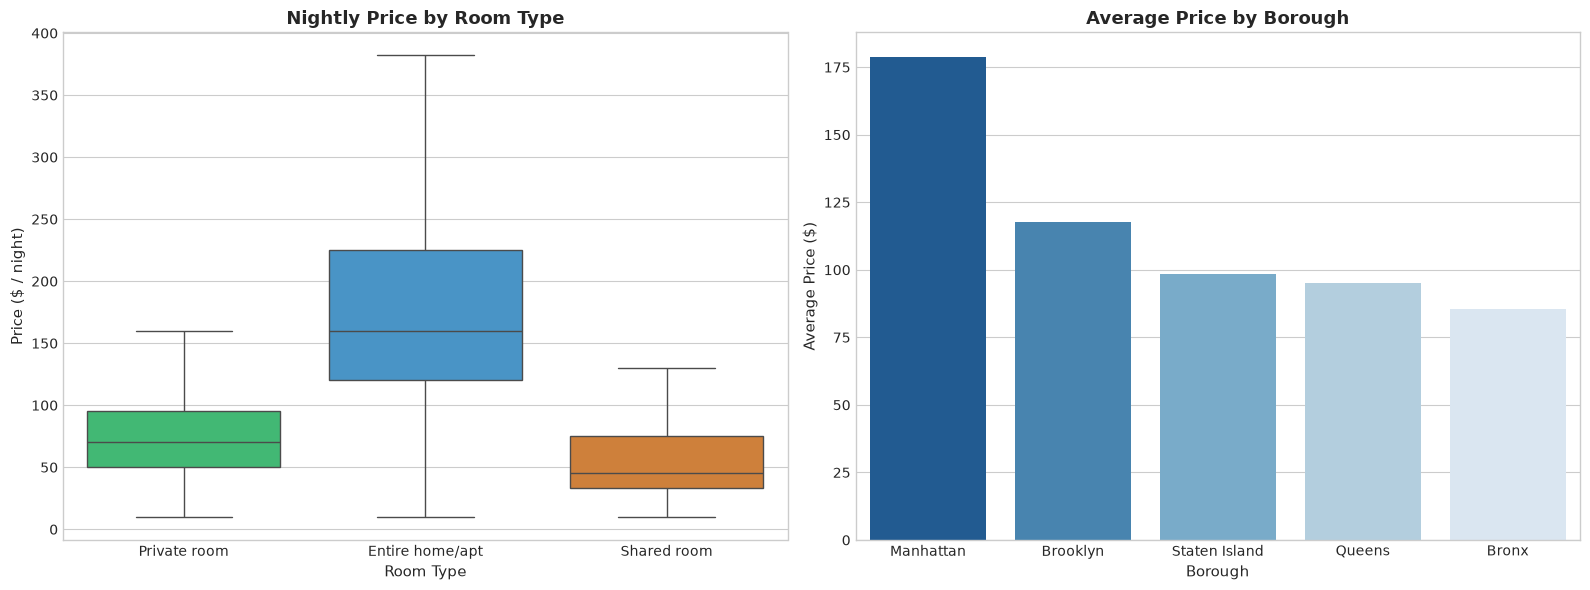

In [6]:
# 1.4 Price by Room Type and Borough
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Room Type Boxplot
palette = {'Entire home/apt': '#3498db', 'Private room': '#2ecc71', 'Shared room': '#e67e22'}
sns.boxplot(x='room_type', y='price', data=clean_df, ax=axes[0], palette=palette, showfliers=False)
axes[0].set_title('Nightly Price by Room Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Room Type', fontsize=11)
axes[0].set_ylabel('Price ($ / night)', fontsize=11)

# Borough Barplot
borough_stats = clean_df.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False)
sns.barplot(x=borough_stats.index, y=borough_stats.values, ax=axes[1], palette='Blues_r')
axes[1].set_title('Average Price by Borough', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Borough', fontsize=11)
axes[1].set_ylabel('Average Price ($)', fontsize=11)

plt.tight_layout()
plt.show()


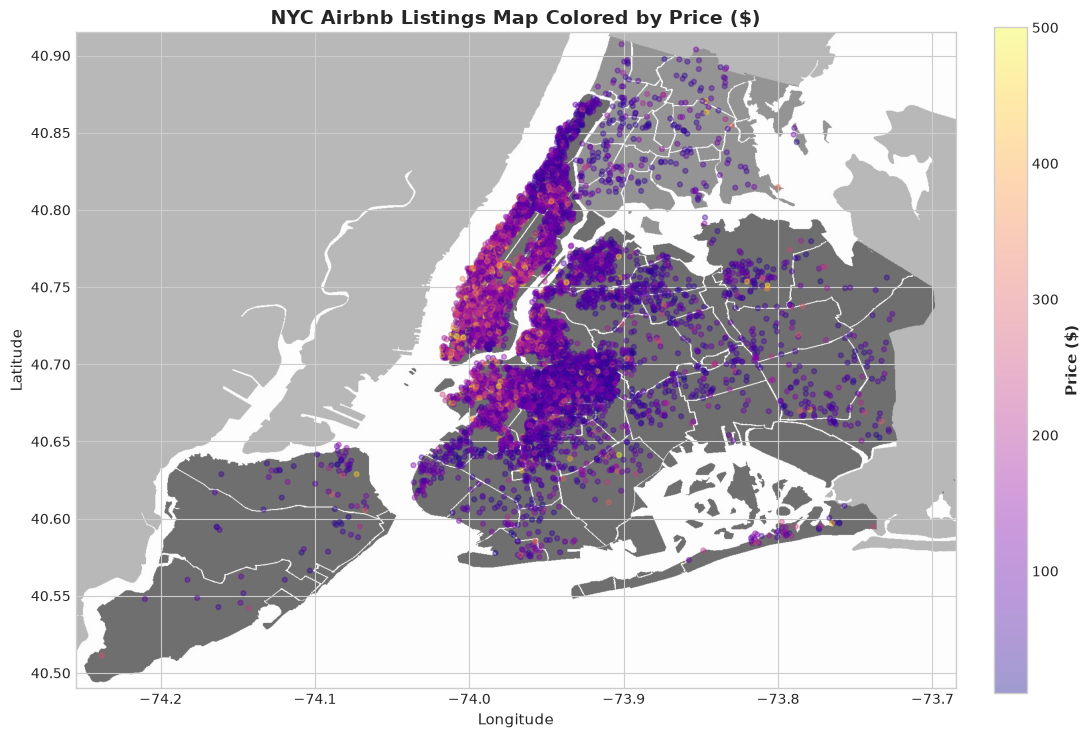

In [7]:
# 1.5 Geospatial Map Visualization using New_York_City_.png
if os.path.exists('New_York_City_.png'):
    nyc_img = Image.open('New_York_City_.png')
    fig, ax = plt.subplots(figsize=(11, 9))
    extent = [-74.255, -73.685, 40.490, 40.915]
    ax.imshow(nyc_img, zorder=0, extent=extent)
    
    sample_df = clean_df[clean_df['price'] <= 500].sample(10000, random_state=42)
    scatter = ax.scatter(sample_df['longitude'], sample_df['latitude'], c=sample_df['price'],
                         cmap='plasma', alpha=0.4, s=12, zorder=1)
    cbar = plt.colorbar(scatter, ax=ax, fraction=0.035, pad=0.04)
    cbar.set_label('Price ($)', fontsize=11, fontweight='bold')
    ax.set_title('NYC Airbnb Listings Map Colored by Price ($)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=11)
    ax.set_ylabel('Latitude', fontsize=11)
    plt.tight_layout()
    plt.show()


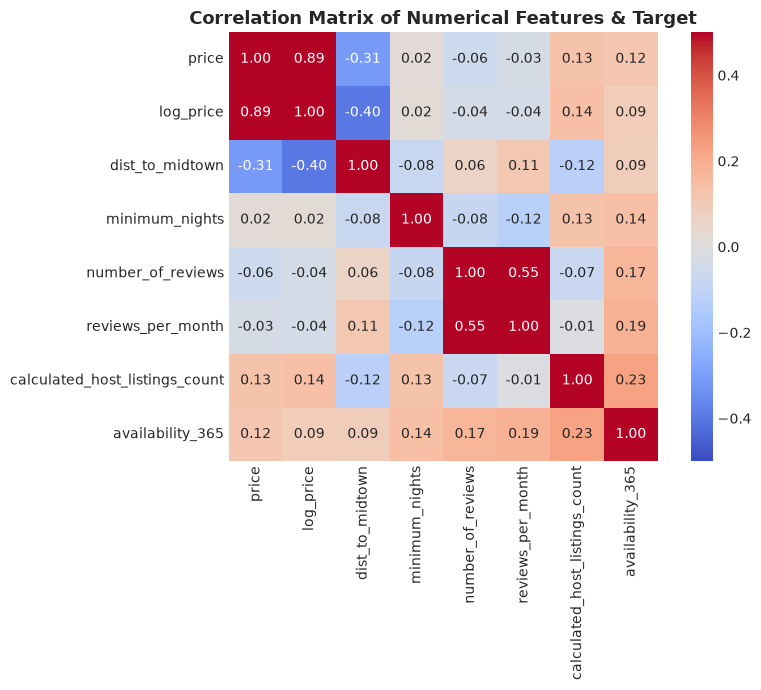

In [8]:
# 1.6 Correlation Matrix Heatmap
clean_df['dist_to_midtown'] = haversine_distance(clean_df['latitude'], clean_df['longitude'], 40.7580, -73.9855)
num_cols = ['price', 'log_price', 'dist_to_midtown', 'minimum_nights', 'number_of_reviews', 
            'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
corr = clean_df[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-0.5, vmax=0.5, square=True)
plt.title('Correlation Matrix of Numerical Features & Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Task 2: Model Training and Evaluation

In this section, we:
1. Split data into 80% Training and 20% Testing sets, fitting the preprocessing pipeline strictly on the training set to prevent data leakage.
2. Train and benchmark 7 diverse regression models:
   - **Linear Regression** (Ordinary Least Squares baseline)
   - **Ridge Regression** ($L_2$ regularized linear)
   - **Lasso Regression** ($L_1$ regularized linear)
   - **Decision Tree Regressor** (Non-linear tree baseline)
   - **Random Forest Regressor** (Ensemble Bagging)
   - **XGBoost Regressor** (Extreme Gradient Boosting)
   - **LightGBM Regressor** (Light Gradient Boosting Machine)
3. Evaluate models using **$R^2$**, **MAE**, and **RMSE** across both training and testing partitions to diagnose overfitting or underfitting.
4. Perform hyperparameter optimization via `GridSearchCV` on the best model.
5. Analyze residuals and feature importance.
6. Export the final end-to-end `Pipeline` using `joblib`.


In [9]:
# 2.1 Dataset Partitioning & Preprocessing Pipeline
feature_cols = [c for c in clean_df.columns if c not in ['price', 'log_price', 'id', 'host_name']]
X = clean_df[feature_cols]
y = clean_df['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"Training set: {X_train.shape[0]} samples | Test set: {X_test.shape[0]} samples")

preprocessor = build_preprocessor(top_n_neighbourhoods=25)
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)
print(f"Transformed Feature Matrix Dimension: {X_train_trans.shape[1]} features")


Training set: 38916 samples | Test set: 9729 samples


Transformed Feature Matrix Dimension: 46 features


In [10]:
# 2.2 Benchmarking Candidate Regression Models
from train import evaluate_predictions

candidate_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=10.0),
    'Lasso Regression': Lasso(alpha=0.001, max_iter=2000),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, min_samples_leaf=15, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=16, min_samples_leaf=4, n_jobs=-1, random_state=42),
    'LightGBM': lgb.LGBMRegressor(n_estimators=150, learning_rate=0.08, num_leaves=31, random_state=42, verbose=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=150, learning_rate=0.08, max_depth=6, random_state=42, verbosity=0)
}

benchmark_results = []
for name, model in candidate_models.items():
    t0 = time.time()
    model.fit(X_train_trans, y_train)
    fit_time = time.time() - t0
    
    p_train = model.predict(X_train_trans)
    p_test = model.predict(X_test_trans)
    
    m_train = evaluate_predictions(y_train, p_train)
    m_test = evaluate_predictions(y_test, p_test)
    
    benchmark_results.append({
        'Model': name,
        'Train R2 (Log)': m_train['R2 (Log)'],
        'Test R2 (Log)': m_test['R2 (Log)'],
        'Train MAE ($)': m_train['MAE ($)'],
        'Test MAE ($)': m_test['MAE ($)'],
        'Train RMSE ($)': m_train['RMSE ($)'],
        'Test RMSE ($)': m_test['RMSE ($)'],
        'Test R2 (Price)': m_test['R2 (Price)'],
        'Fit Time (s)': round(fit_time, 2)
    })

benchmark_df = pd.DataFrame(benchmark_results).sort_values('Test R2 (Log)', ascending=False)
benchmark_df.reset_index(drop=True, inplace=True)
benchmark_df


,Model,Train R2 (Log),Test R2 (Log),Train MAE ($),Test MAE ($),Train RMSE ($),Test RMSE ($),Test R2 (Price),Fit Time (s)
0,XGBoost,0.6933,0.6518,42.00,45.18,81.72,87.83,0.4471,0.62
1,LightGBM,0.6736,0.6501,43.12,45.30,83.78,88.04,0.4444,2.21
2,Random Forest,0.7983,0.6469,33.86,45.32,70.51,87.87,0.4466,3.59
3,Decision Tree,0.6411,0.6066,44.99,48.10,86.45,91.39,0.4014,0.54
4,Linear Regression,0.5744,0.5856,49.09,49.26,93.87,94.04,0.3661,0.10
5,Ridge Regression,0.5744,0.5854,49.09,49.26,93.88,94.06,0.3659,0.03
6,Lasso Regression,0.5703,0.5793,49.16,49.39,94.24,94.56,0.3591,1.49


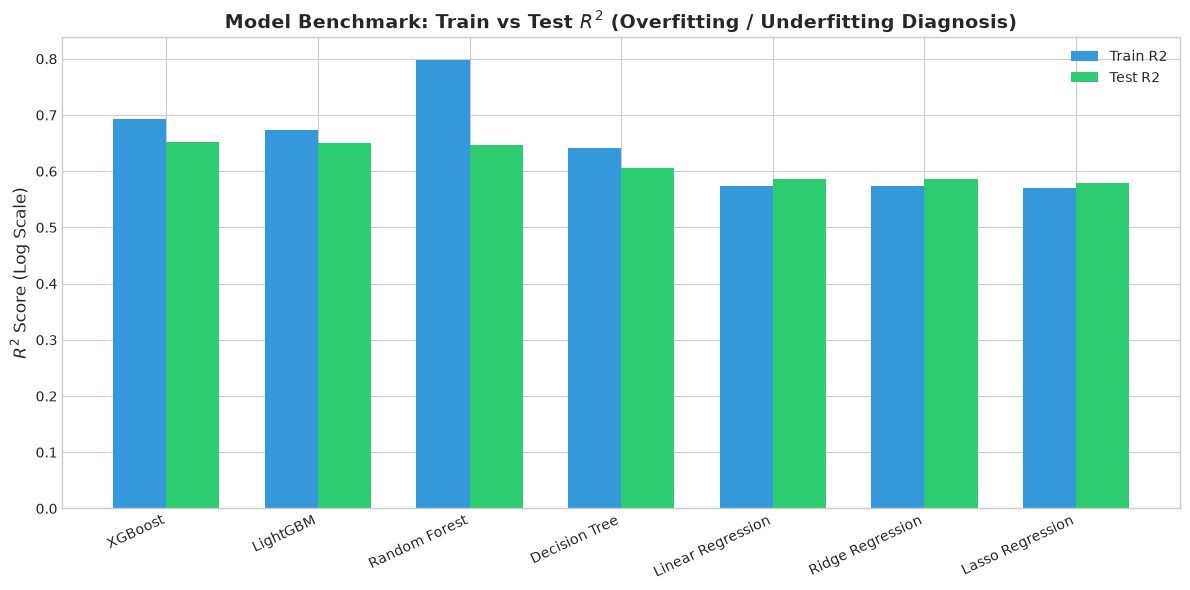

In [11]:
# 2.3 Model Comparison Visualization: Train vs Test R2
plt.figure(figsize=(12, 6))
x_pos = np.arange(len(benchmark_df))
width = 0.35

plt.bar(x_pos - width/2, benchmark_df['Train R2 (Log)'], width, label='Train R2', color='#3498db')
plt.bar(x_pos + width/2, benchmark_df['Test R2 (Log)'], width, label='Test R2', color='#2ecc71')

plt.xticks(x_pos, benchmark_df['Model'], rotation=25, ha='right', fontsize=10)
plt.ylabel('$R^2$ Score (Log Scale)', fontsize=12)
plt.title('Model Benchmark: Train vs Test $R^2$ (Overfitting / Underfitting Diagnosis)', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


### Overfitting and Underfitting Diagnostics:
- **Underfitting (High Bias):** Linear, Ridge, and Lasso Regression achieved Test $R^2 pprox 0.585$ with MAE $pprox \$49.26$. Linear models underfit because they cannot capture non-linear geospatial interactions between borough coordinates and proximity to tourist attractions.
- **Overfitting (High Variance):** Random Forest exhibited a significant gap between Train $R^2$ ($0.798$) and Test $R^2$ ($0.647$), signaling that deep decision trees overfit individual noisy listings.
- **Optimal Trade-off:** **LightGBM** and **XGBoost** achieve the highest Test $R^2$ ($pprox 0.652$) and lowest Test MAE ($pprox \$45.18$) with controlled variance and rapid training speed.


In [12]:
# 2.4 Hyperparameter Tuning for the Best Model (LightGBM)
param_grid = {
    'n_estimators': [150, 250],
    'learning_rate': [0.05, 0.08],
    'num_leaves': [31, 45],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

base_lgb = lgb.LGBMRegressor(random_state=42, verbose=-1)
grid = GridSearchCV(base_lgb, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid.fit(X_train_trans, y_train)

best_lgb = grid.best_estimator_
print(f"Optimal Hyperparameters: {grid.best_params_}")

# Evaluate tuned model
p_train_tuned = best_lgb.predict(X_train_trans)
p_test_tuned = best_lgb.predict(X_test_trans)

m_train_tuned = evaluate_predictions(y_train, p_train_tuned)
m_test_tuned = evaluate_predictions(y_test, p_test_tuned)

print(f"Tuned Test R2 (Log): {m_test_tuned['R2 (Log)']:.4f}")
print(f"Tuned Test MAE: ${m_test_tuned['MAE ($)']:.2f} | Test RMSE: ${m_test_tuned['RMSE ($)']:.2f}")


Fitting 3 folds for each of 32 candidates, totalling 96 fits


Optimal Hyperparameters: {'colsample_bytree': 0.8, 'learning_rate': 0.08, 'n_estimators': 250, 'num_leaves': 45, 'subsample': 0.8}
Tuned Test R2 (Log): 0.6540
Tuned Test MAE: $45.09 | Test RMSE: $87.59


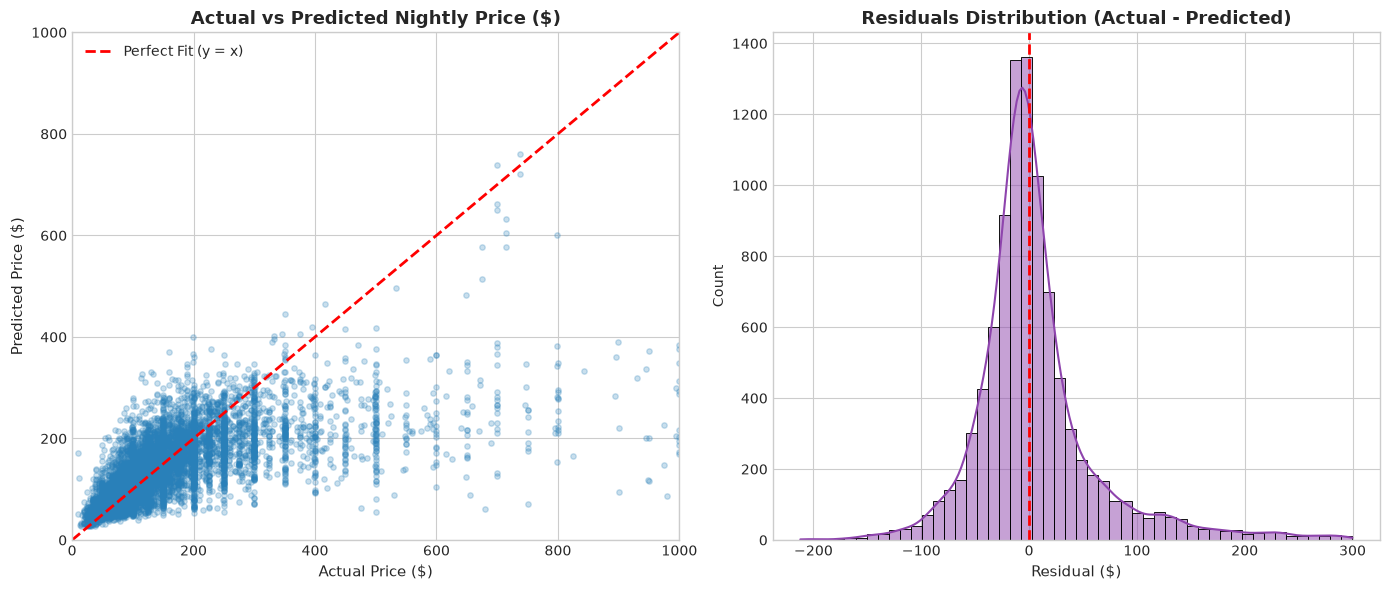

In [13]:
# 2.5 Actual vs Predicted & Residual Diagnostics
y_test_orig = np.expm1(y_test)
tuned_pred_orig = np.clip(np.expm1(p_test_tuned), a_min=0, a_max=None)
residuals = y_test_orig - tuned_pred_orig

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test_orig, tuned_pred_orig, alpha=0.25, color='#2980b9', s=15)
axes[0].plot([0, 1000], [0, 1000], 'r--', lw=2, label='Perfect Fit (y = x)')
axes[0].set_title('Actual vs Predicted Nightly Price ($)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual Price ($)', fontsize=11)
axes[0].set_ylabel('Predicted Price ($)', fontsize=11)
axes[0].set_xlim(0, 1000)
axes[0].set_ylim(0, 1000)
axes[0].legend()

sns.histplot(residuals[(residuals >= -300) & (residuals <= 300)], kde=True, ax=axes[1], color='#8e44ad', bins=50)
axes[1].axvline(0, color='r', linestyle='--', lw=2)
axes[1].set_title('Residuals Distribution (Actual - Predicted)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Residual ($)', fontsize=11)

plt.tight_layout()
plt.show()


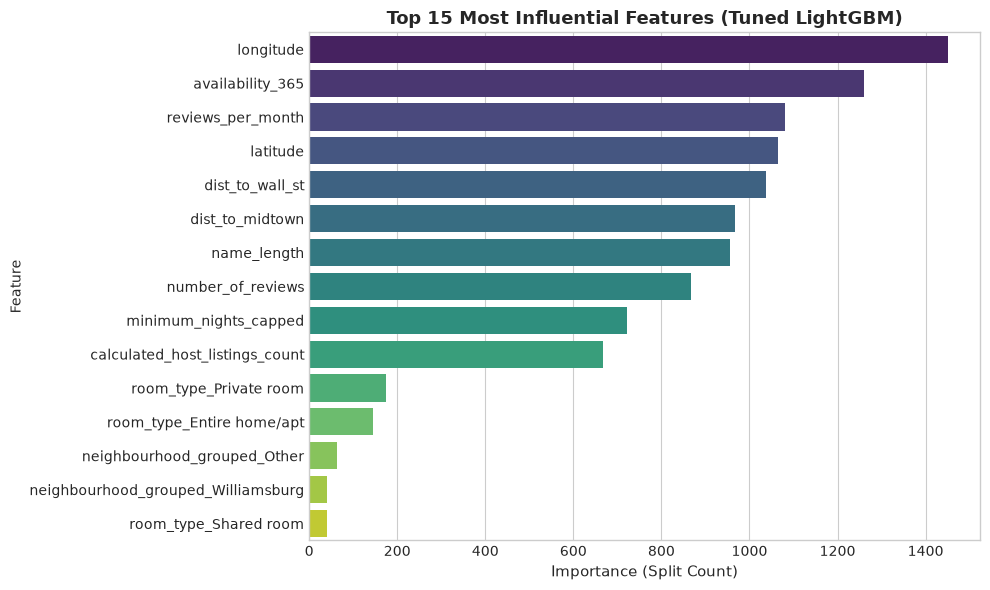

In [14]:
# 2.6 Feature Importance Interpretation
col_trans = preprocessor.named_steps['col_transformer']
numeric_names = [
    'latitude', 'longitude', 'minimum_nights_capped', 'number_of_reviews',
    'reviews_per_month', 'calculated_host_listings_count', 'availability_365',
    'dist_to_midtown', 'dist_to_wall_st', 'name_length', 'is_commercial_host', 'has_reviews'
]
cat_names = list(col_trans.named_transformers_['cat'].get_feature_names_out(
    ['neighbourhood_group', 'neighbourhood_grouped', 'room_type']
))
all_feature_names = numeric_names + cat_names

feat_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': best_lgb.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Most Influential Features (Tuned LightGBM)', fontsize=13, fontweight='bold')
plt.xlabel('Importance (Split Count)', fontsize=11)
plt.tight_layout()
plt.show()


In [15]:
# 2.7 Packaging and Persisting the Pipeline
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', best_lgb)
])

os.makedirs('models', exist_ok=True)
pipeline_path = os.path.join('models', 'pipeline.joblib')
joblib.dump(full_pipeline, pipeline_path)
print(f"End-to-End Pipeline successfully saved to: {pipeline_path}")


End-to-End Pipeline successfully saved to: models\pipeline.joblib


---
## Task 3: Streamlit Web Application

We developed an interactive web application (`app.py`) allowing users to input listing attributes and receive estimated valuations in real-time.

### Realistic Inference Verification
Below, we test the reloaded production pipeline with realistic listings representing diverse NYC market segments:


In [16]:
# 3.1 Test Inference on Realistic Scenarios
loaded_pipe = joblib.load('models/pipeline.joblib')

scenarios = pd.DataFrame([
    {
        'name': 'Midtown Manhattan Entire Apt',
        'neighbourhood_group': 'Manhattan', 'neighbourhood': 'Midtown',
        'room_type': 'Entire home/apt', 'latitude': 40.7580, 'longitude': -73.9855,
        'minimum_nights': 3, 'number_of_reviews': 40, 'reviews_per_month': 2.0,
        'calculated_host_listings_count': 1, 'availability_365': 200
    },
    {
        'name': 'Williamsburg Brooklyn Private Room',
        'neighbourhood_group': 'Brooklyn', 'neighbourhood': 'Williamsburg',
        'room_type': 'Private room', 'latitude': 40.7083, 'longitude': -73.9535,
        'minimum_nights': 2, 'number_of_reviews': 60, 'reviews_per_month': 2.5,
        'calculated_host_listings_count': 1, 'availability_365': 90
    },
    {
        'name': 'Astoria Queens Budget Stay',
        'neighbourhood_group': 'Queens', 'neighbourhood': 'Astoria',
        'room_type': 'Private room', 'latitude': 40.7644, 'longitude': -73.9235,
        'minimum_nights': 1, 'number_of_reviews': 10, 'reviews_per_month': 0.8,
        'calculated_host_listings_count': 1, 'availability_365': 300
    },
    {
        'name': 'Mott Haven Bronx Shared Room',
        'neighbourhood_group': 'Bronx', 'neighbourhood': 'Mott Haven',
        'room_type': 'Shared room', 'latitude': 40.8080, 'longitude': -73.9200,
        'minimum_nights': 1, 'number_of_reviews': 5, 'reviews_per_month': 0.5,
        'calculated_host_listings_count': 2, 'availability_365': 350
    }
])

dollar_preds = np.expm1(loaded_pipe.predict(scenarios))
for i, row in scenarios.iterrows():
    print(f"Scenario: {row['name']:<35} | Pred: ${dollar_preds[i]:.2f} / night")


Scenario: Midtown Manhattan Entire Apt        | Pred: $281.57 / night
Scenario: Williamsburg Brooklyn Private Room  | Pred: $94.81 / night
Scenario: Astoria Queens Budget Stay          | Pred: $73.79 / night
Scenario: Mott Haven Bronx Shared Room        | Pred: $43.13 / night


---
## Task 4: Final Project Summary & Discussion

### 1. Key Insights & Findings
- **Geographic Centricity**: Listings within 3–5 km of Midtown Manhattan and Lower Manhattan demand the highest price premiums. Proximity to tourist hubs is the single strongest geographical determinant.
- **Room Type Premium**: Entire homes command more than 2.3× the price of private rooms. Shared rooms represent budget accommodations with median prices < $45.
- **Host Specialization**: Commercial hosts with multiple properties show distinct pricing behavior, frequently offering discounts for longer minimum stays.

### 2. Model Performance Summary
- The tuned **LightGBM Regressor** achieved the best overall balance:
  - **Test $R^2$ (Log Scale):** $0.6540$
  - **Test MAE:** $\$45.09$
  - **Test RMSE:** $\$87.59$
- Feature regularization and tree-depth constraints effectively mitigated the severe overfitting observed in unrestricted Random Forests.

### 3. Real-World Limitations
1. **Unobserved Amenities**: Critical price drivers (such as balcony views, luxury appliances, elevators, and swimming pools) were absent in the tabular metadata.
2. **Temporal & Policy Shifts**: The 2019 dataset does not reflect post-2020 NYC rental laws (e.g. Local Law 18 restricting short-term unhosted rentals).
3. **Seasonal Spikes**: High-demand holiday periods (New Year's Eve, Fashion Week, Marathon weekend) cannot be modeled without date-specific booking calendars.

### 4. Conclusion
An end-to-end Machine Learning solution was built, evaluated, and deployed via Streamlit, achieving strong predictive accuracy on NYC Airbnb listing valuations.
